In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [348]:
df=pd.read_csv('HR_dataset.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [350]:
df = df.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident',
    'time_spend_company': 'tenure',
    'Department': 'department'
})

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   tenure                 14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [354]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [356]:
df.duplicated().sum()

3008

In [358]:
df1=df.drop_duplicates(keep='first')
df1.shape

(11991, 10)

In [360]:
df1.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [362]:
df1['left'].value_counts(normalize='True')

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64

In [364]:
df1['salary'].value_counts(normalize='True')

salary
low       0.478692
medium    0.438746
high      0.082562
Name: proportion, dtype: float64

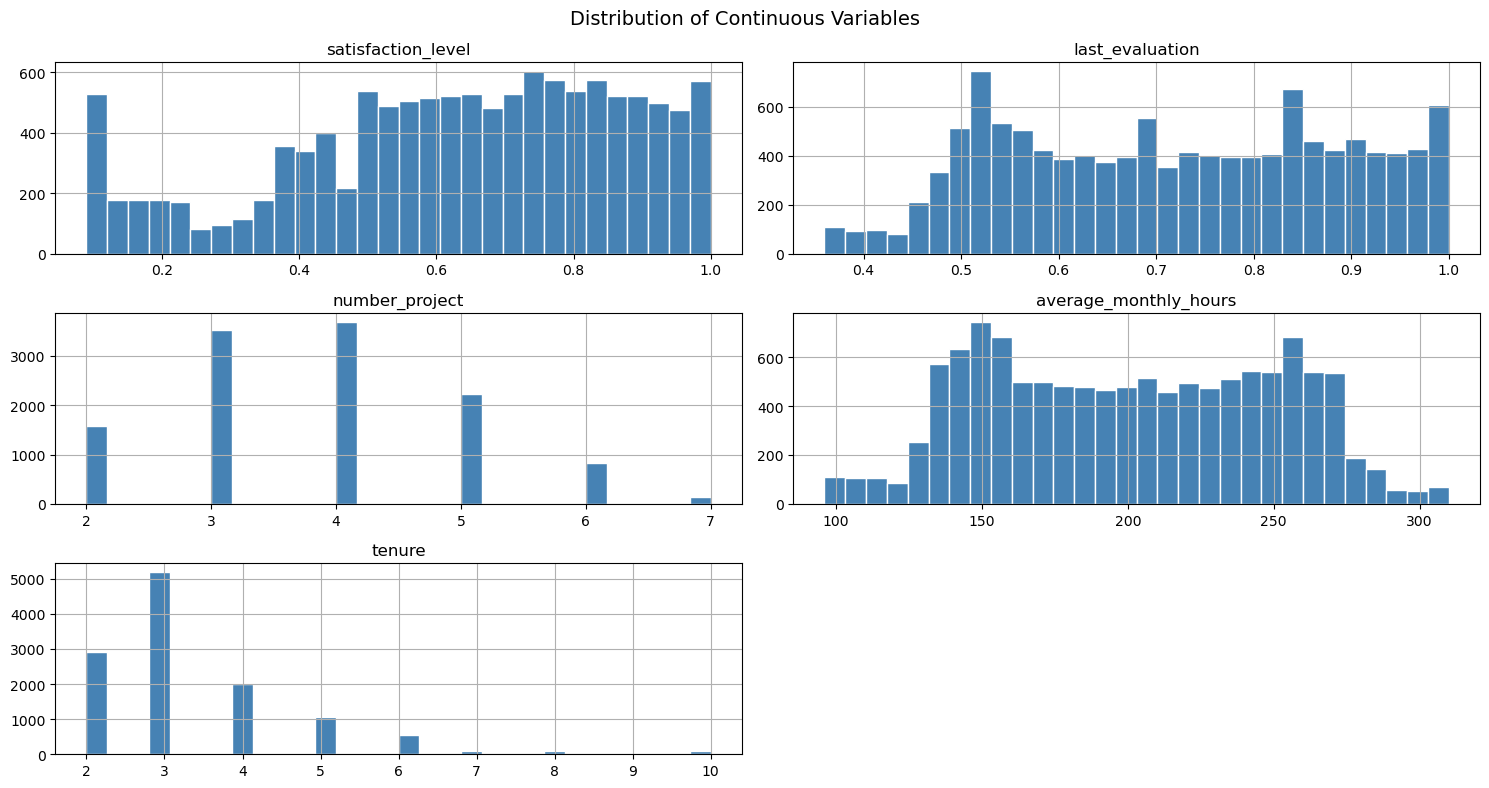

In [366]:
# distribution of continuous variables
continuous_cols = ['satisfaction_level', 'last_evaluation', 
                   'number_project', 'average_monthly_hours', 
                   'tenure']

df1[continuous_cols].hist(bins=30, figsize=(15, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Continuous Variables', fontsize=14)
plt.tight_layout()
plt.show()

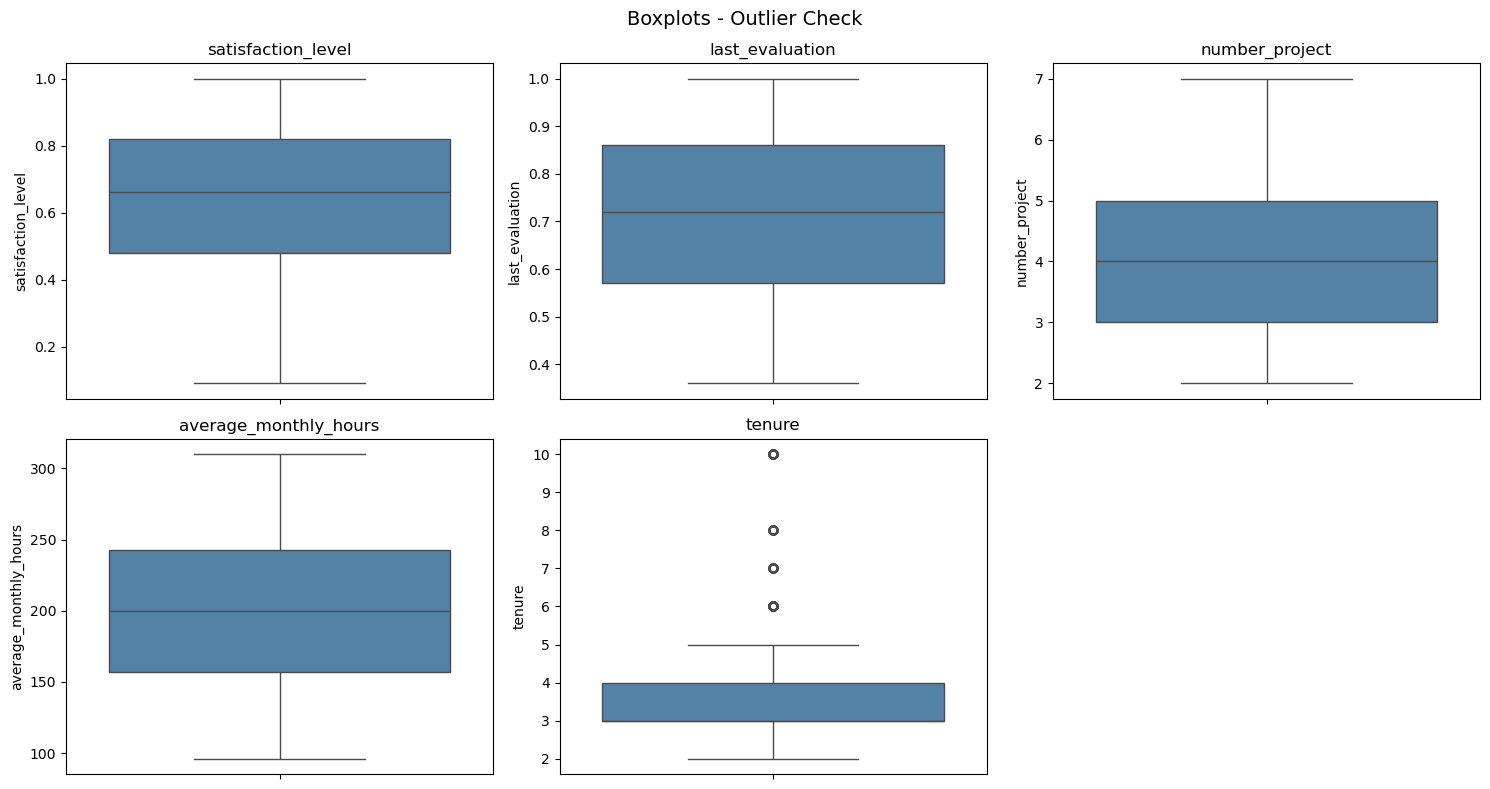

In [367]:
# check the outliers of the continuous variables using boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df1[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

axes[5].set_visible(False)
plt.suptitle('Boxplots - Outlier Check', fontsize=14)
plt.tight_layout()
plt.show()

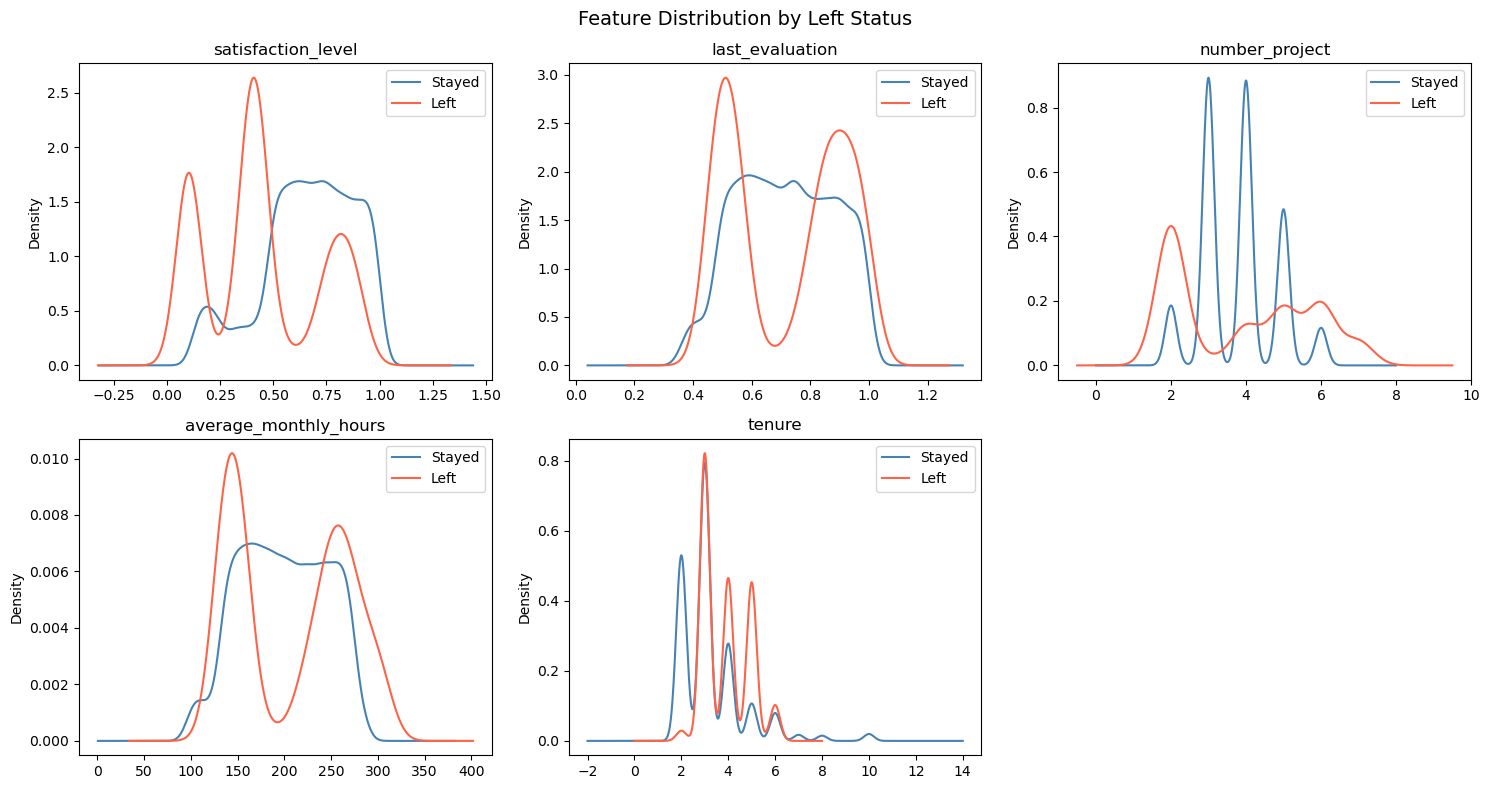

In [535]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    df1[df1['left'] == 0][col].plot(kind='kde', ax=axes[i], label='Stayed', color='steelblue')
    df1[df1['left'] == 1][col].plot(kind='kde', ax=axes[i], label='Left', color='tomato')
    axes[i].set_title(col)
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Feature Distribution by Left Status', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

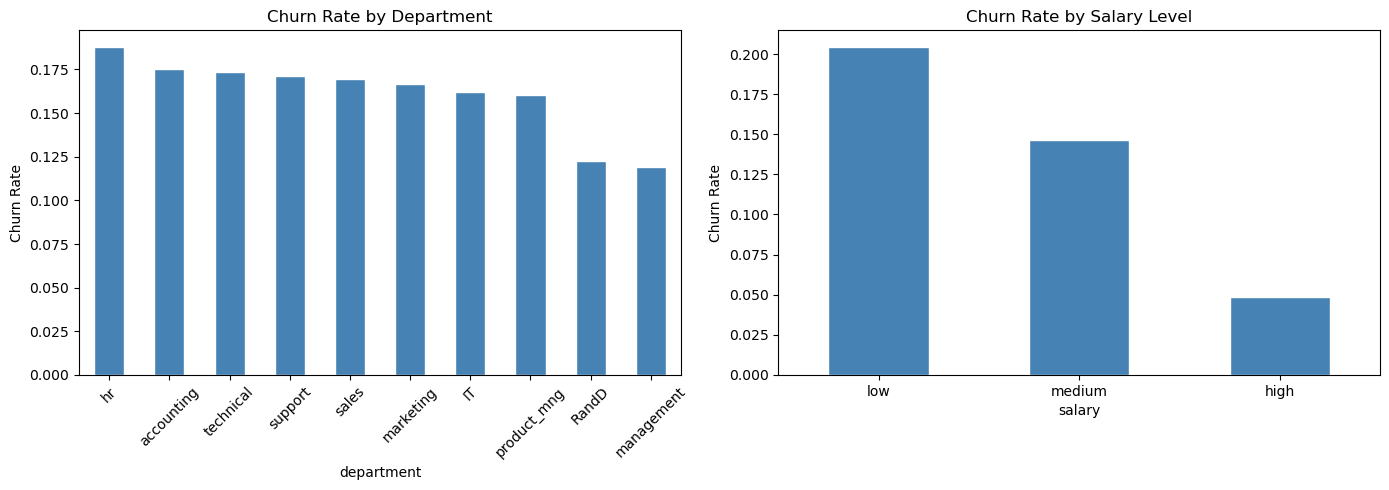

In [537]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# churn rate by department
dept_churn = df1.groupby('department')['left'].mean().sort_values(ascending=False)
dept_churn.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Department')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

# churn rate by salary level
salary_churn = df1.groupby('salary')['left'].mean().reindex(['low', 'medium', 'high'])
salary_churn.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Churn Rate by Salary Level')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

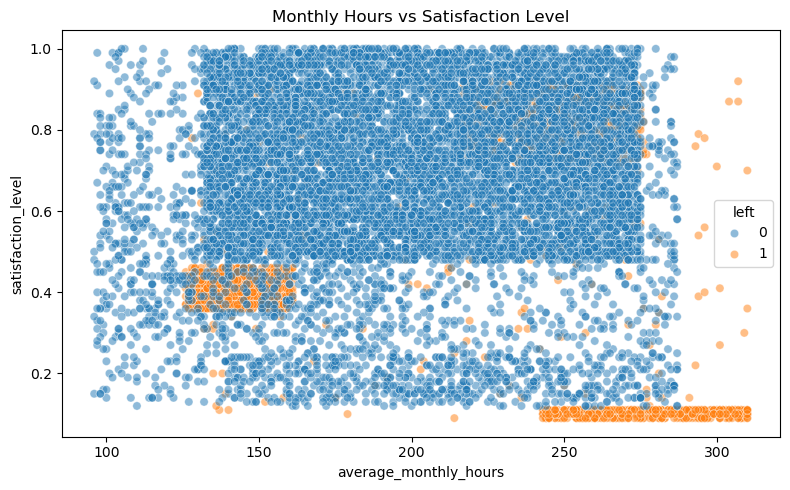

In [539]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', 
                hue='left', alpha=0.5)
plt.title('Monthly Hours vs Satisfaction Level')
plt.tight_layout()
plt.savefig('hours_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

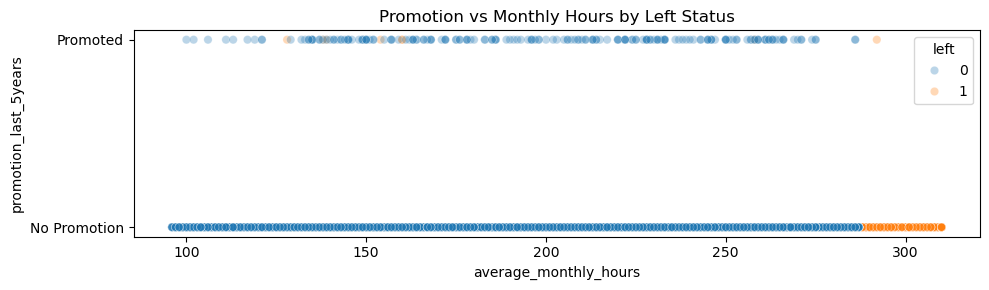

In [541]:
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', 
                hue='left', alpha=0.3)
plt.title('Promotion vs Monthly Hours by Left Status')
plt.yticks([0, 1], ['No Promotion', 'Promoted'])
plt.tight_layout()
plt.savefig('promotion_vs_hours.png', dpi=150, bbox_inches='tight')
plt.show()

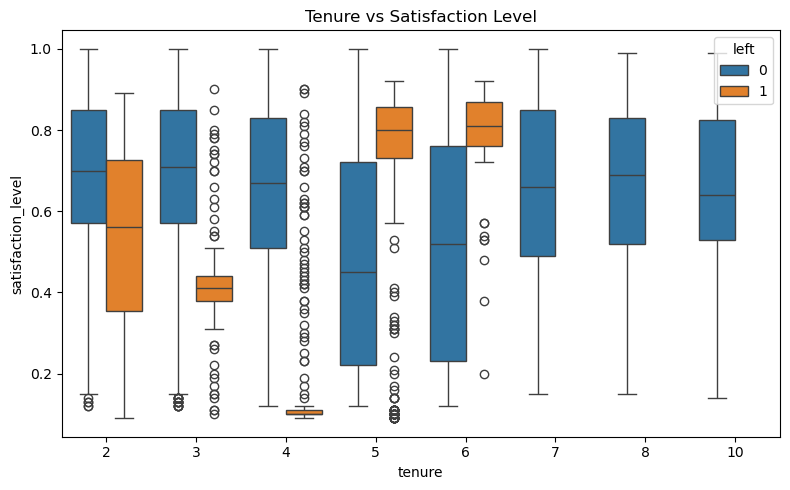

In [543]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df1, x='tenure', y='satisfaction_level', hue='left')
plt.title('Tenure vs Satisfaction Level')
plt.tight_layout()
plt.savefig('tenure_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

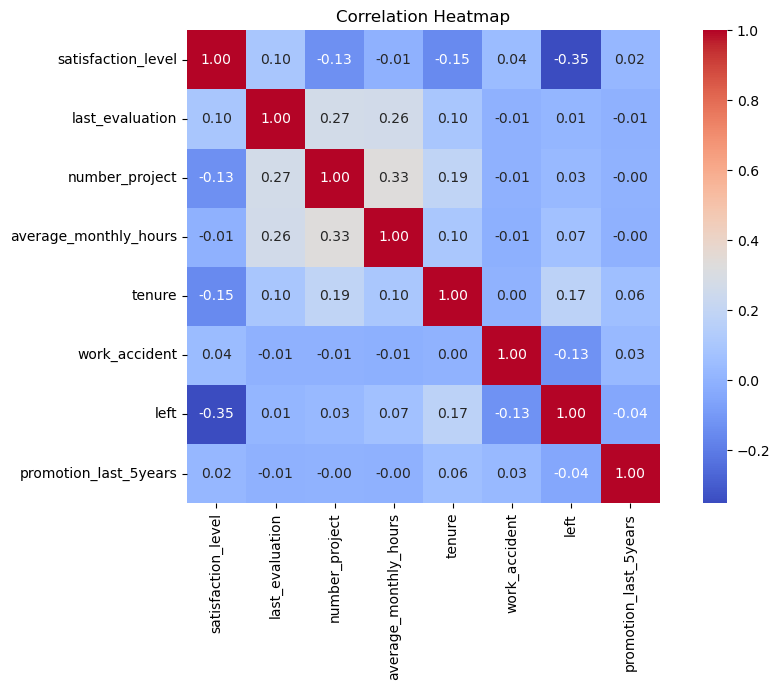

In [374]:
plt.figure(figsize=(10, 7))
corr = df1.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [524]:
# contingency table
contingency_table = pd.crosstab(df1['salary'], df1['left'])
print(contingency_table)

# chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-square: {round(chi2, 3)}')
print(f'P-value: {round(p_value, 3)}')

left       0     1
salary            
high     942    48
low     4566  1174
medium  4492   769
Chi-square: 175.211
P-value: 0.0


In [375]:
# features for clustering
cluster_features = ['satisfaction_level', 'last_evaluation', 
                    'number_project', 'average_monthly_hours', 'tenure']

X = df1[cluster_features]

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

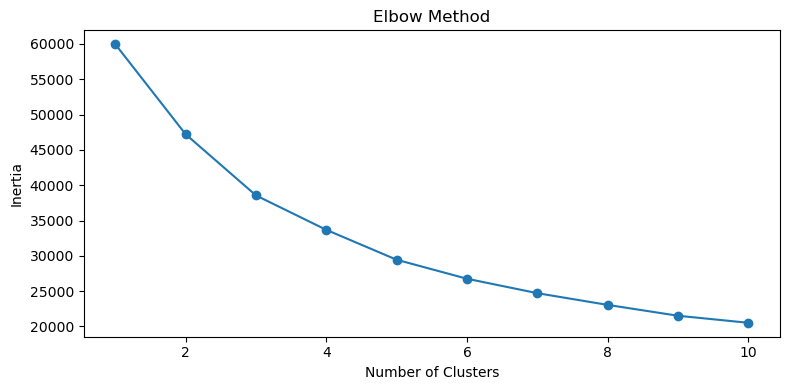

In [377]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [378]:
# train k-means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df1 = df1.copy()
df1['cluster'] = km.fit_predict(X_scaled)

# check cluster distribution
df1['cluster'].value_counts()

cluster
1    6277
2    3367
0    2347
Name: count, dtype: int64

In [379]:
cluster_summary = df1.groupby('cluster')[cluster_features].mean().round(2)
cluster_summary

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure
cluster,,,,,
0,0.42,0.81,4.98,234.01,5.08
1,0.76,0.77,3.82,210.58,2.85
2,0.53,0.56,2.95,158.25,3.13


In [380]:
churn_by_cluster = df1.groupby('cluster')['left'].mean().round(3)
print(churn_by_cluster)

cluster
0    0.420
1    0.022
2    0.258
Name: left, dtype: float64


In [381]:
cluster_salary = df1.groupby(['cluster', 'salary'])['left'].count().unstack()
cluster_salary_pct = cluster_salary.div(cluster_salary.sum(axis=1), axis=0).round(2)
print(cluster_salary_pct)

salary   high   low  medium
cluster                    
0        0.08  0.49    0.43
1        0.09  0.46    0.45
2        0.08  0.50    0.42


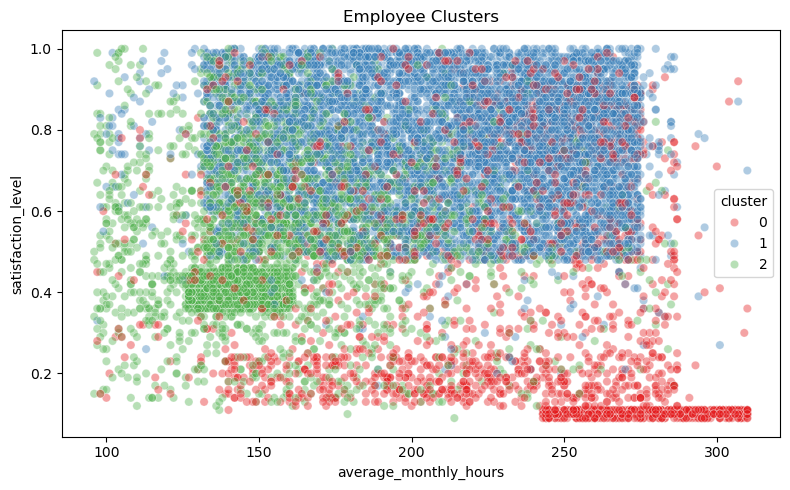

In [545]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level',
                hue='cluster', palette='Set1', alpha=0.4)
plt.title('Employee Clusters')
plt.tight_layout()
plt.savefig('employee_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [383]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df1['cluster'])
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.220


In [385]:
# encode categorical variables
df_model = df1.copy()
df_model['salary'] = df_model['salary'].map({'low': 0, 'medium': 1, 'high': 2})
df_model = pd.get_dummies(df_model, columns=['department'], drop_first=True, dtype=int)

# features and target
X = df_model.drop(columns=['left'])
y = df_model['left']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [387]:
df_model.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,cluster,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,2,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,2,0,0,0,0,0,0,1,0,0


In [440]:
# train logistic regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_test)

In [441]:
# evaluate on train set
y_train_pred = lr.predict(X_train)
print('Train Set:')
print(classification_report(y_train, y_train_pred))

# evaluate on test set
print('Test Set:')
print(classification_report(y_test, y_pred))

Train Set:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      8002
           1       0.40      0.82      0.54      1590

    accuracy                           0.77      9592
   macro avg       0.68      0.79      0.69      9592
weighted avg       0.86      0.77      0.79      9592

Test Set:
              precision    recall  f1-score   support

           0       0.96      0.77      0.86      1998
           1       0.42      0.84      0.56       401

    accuracy                           0.78      2399
   macro avg       0.69      0.80      0.71      2399
weighted avg       0.87      0.78      0.81      2399



In [442]:
param_grid = {
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 6]
}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(dt, param_grid, scoring=scoring, 
                           cv=5, refit='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)
print('Best params:', grid_search.best_params_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [443]:
dt_best = grid_search.best_estimator_

y_train_pred_dt = dt_best.predict(X_train)
y_test_pred_dt = dt_best.predict(X_test)

print('Train Set:')
print(classification_report(y_train, y_train_pred_dt))

print('Test Set:')
print(classification_report(y_test, y_test_pred_dt))

Train Set:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      8002
           1       0.85      1.00      0.92      1590

    accuracy                           0.97      9592
   macro avg       0.92      0.98      0.95      9592
weighted avg       0.97      0.97      0.97      9592

Test Set:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1998
           1       0.80      0.92      0.85       401

    accuracy                           0.95      2399
   macro avg       0.89      0.93      0.91      2399
weighted avg       0.95      0.95      0.95      2399



In [444]:
def make_results(model_name, model_object, metric):
    
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'}
    
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_row = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [best_row.mean_test_precision],
        'recall': [best_row.mean_test_recall],
        'f1': [best_row.mean_test_f1],
        'accuracy': [best_row.mean_test_accuracy],
        'auc': [best_row.mean_test_roc_auc]
    })
    
    return table

# get decision tree results
dt_results = make_results('Decision Tree', grid_search, 'auc')
print(dt_results)

           model  precision    recall       f1  accuracy      auc
0  Decision Tree   0.783352  0.925786  0.84851  0.945162  0.96031


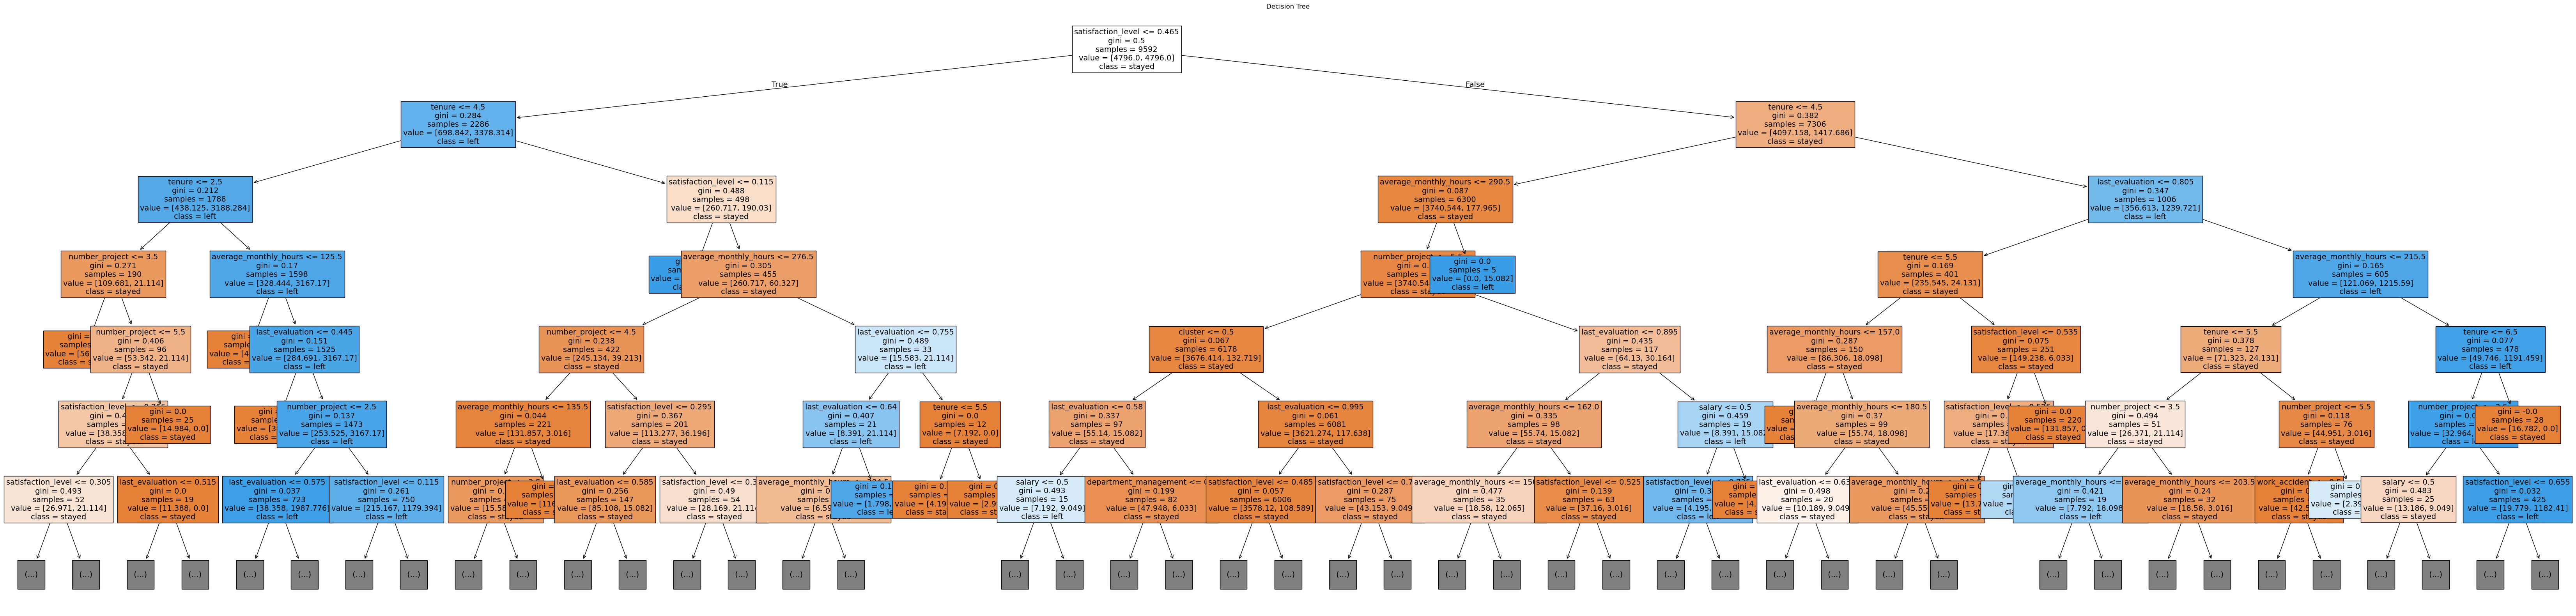

In [547]:
plt.figure(figsize=(85, 20))
plot_tree(grid_search.best_estimator_, max_depth=6, fontsize=14, 
          feature_names=X.columns, 
          class_names={0:'stayed', 1:'left'}, 
          filled=True)
plt.title('Decision Tree')
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [486]:
param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 6]
}

rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    cv=5,
    refit='roc_auc',
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Best params:', rf.best_params_)


Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 300}


In [487]:
rf_results = make_results('Random Forest', rf, 'auc')
print(rf_results)

           model  precision    recall        f1  accuracy       auc
0  Random Forest   0.983158  0.913836  0.947147  0.983111  0.982525


In [488]:
all_results = pd.concat([dt_results, rf_results], ignore_index=True)
print(all_results)

           model  precision    recall        f1  accuracy       auc
0  Decision Tree   0.783352  0.925786  0.848510  0.945162  0.960310
1  Random Forest   0.983158  0.913836  0.947147  0.983111  0.982525


In [489]:
print(X.columns.tolist())

['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'promotion_last_5years', 'salary', 'cluster', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']


In [494]:
param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'min_child_weight': [1, 3]
}

xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=5, random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    cv=5,
    refit='roc_auc',
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print('Best params:', xgb.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}


In [496]:
xgb_results = make_results('XGBoost', xgb, 'auc')

all_results = pd.concat([dt_results, rf_results, xgb_results], ignore_index=True)
print(all_results)

           model  precision    recall        f1  accuracy       auc
0  Decision Tree   0.783352  0.925786  0.848510  0.945162  0.960310
1  Random Forest   0.983158  0.913836  0.947147  0.983111  0.982525
2        XGBoost   0.898897  0.937736  0.917817  0.972164  0.987445


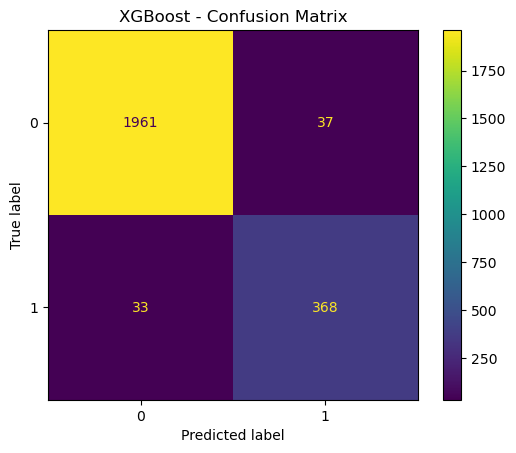

In [516]:
# best model and predictions on test set
xgb_best = xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title('XGBoost - Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [512]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1998
           1       0.91      0.92      0.91       401

    accuracy                           0.97      2399
   macro avg       0.95      0.95      0.95      2399
weighted avg       0.97      0.97      0.97      2399



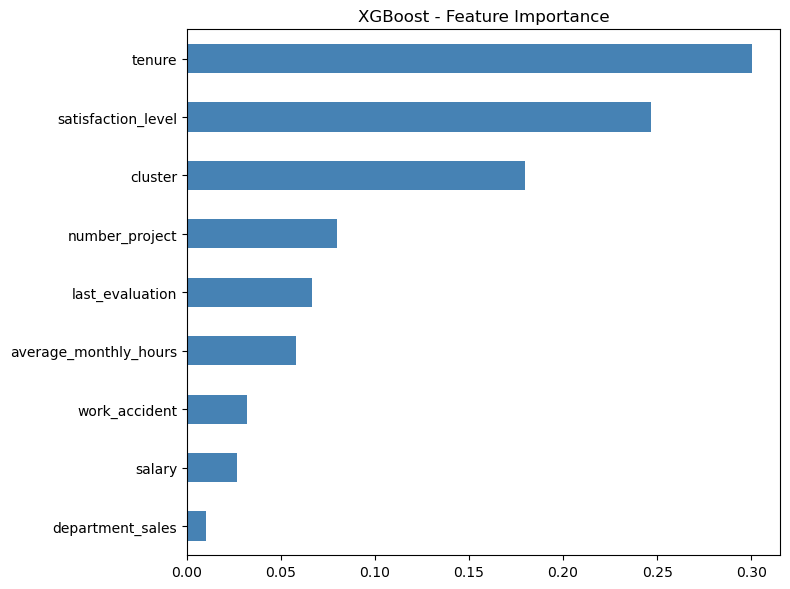

In [530]:
feat_importance = pd.Series(xgb_best.feature_importances_, index=X.columns)
feat_importance[feat_importance > 0].sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [533]:
# save model
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)